# **SETUP**

In [2]:
from collections import defaultdict

import cv2
import numpy as np


import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc as rc
import IPython.display
import matplotlib as mpl

# Set the animation embed limit to 50 MB
mpl.rcParams['animation.embed_limit'] = 1000
rc('animation', html='jshtml')

# from google.colab import drive
# drive.mount('/content/drive')

# **VIDEO PLAYER**

In [3]:
def draw_text(img, text,
          pos=(0, 0),
          font=cv2.FONT_HERSHEY_PLAIN,
          font_scale=3.0,
          font_thickness=2,
          text_color=(0, 255, 0),
          text_color_bg=(0, 0, 0)
          ):

    x, y = pos
    text_size, _ = cv2.getTextSize(text, font, font_scale, font_thickness)
    text_w, text_h = text_size
    cv2.rectangle(img, pos, (x + text_w, y + text_h), text_color_bg, -1)
    cv2.putText(img, text, (x, round(y + text_h + font_scale - 1)), font, font_scale, text_color, font_thickness)

    return text_size

In [36]:
class VideoPlayer:
    def __init__(self, video_path):
        self.video_path = video_path
        self.cap = cv2.VideoCapture(video_path)
        if not self.cap.isOpened():
            raise ValueError(f"Could not open video file: {video_path}")

        self.frame_count = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
        self.width = int(self.cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.height = int(self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        self.figsize = (5, round(5 / self.width * self.height))

        print(self.figsize)

        # Close immediately if you only need the metadata
        self.cap.release()

    def get_frames(self, start_frame, end_frame):
        """
        Returns all frames in RGB from start_frame (inclusive) to end_frame (exclusive).
        """
        if start_frame >= self.frame_count:
            return np.array([])

        cap = cv2.VideoCapture(self.video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        frames = []
        for frame_idx in range(start_frame, end_frame):
            if frame_idx >= self.frame_count:
                break
            ret, frame = cap.read()
            if not ret:
                break
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
        cap.release()
        return np.array(frames)

    def plot(
        self,
        start_frame=0,
        end_frame=100,
        bounding_boxes_gt=None,
        bounding_boxes_pred=None,
        gt_color=(0, 255, 0),
        pred_color=(255, 0, 0),
        bbox_thickness=5,
        save_file=None,
        taking_only_GTobject_into_account=False,
        iou_threshold=0.01,
    ):
        """
        Displays an animation of the video frames within [start_frame, end_frame).
        Optionally draws bounding boxes for ground-truth and predicted data,
        with track IDs rendered in a small filled square of the same color.
        
        If taking_only_GTobject_into_account is True, predicted bounding boxes
        will be filtered per frame based on an IoU threshold with the GT boxes.
        """
        frames = self.get_frames(start_frame-1, end_frame-1)
        if len(frames) == 0:
            print("No frames to display for the specified frame range.")
            return

        processed_frames = []
        label_box_size = 30  # Size (width=height) of the track ID "label box"

        for i, frame in enumerate(frames):
            # Convert to uint8 for drawing bounding boxes in OpenCV
            out_frame_uint8 = frame.astype(np.uint8)

            try:
                # Draw ground-truth bounding boxes
                if bounding_boxes_gt is not None:
                    for gt_box in bounding_boxes_gt[i + start_frame]:
                        x, y, w, h = gt_box["bbox"]
                        # Draw the bounding box
                        cv2.rectangle(
                            out_frame_uint8,
                            (int(x), int(y)), (int(x + w), int(y + h)),
                            color=gt_color,
                            thickness=bbox_thickness
                        )
                        # Draw the track_id box (if present)
                        if "track_id" in gt_box:
                            tid = str(gt_box["track_id"])
                            # Draw a small filled square near the top-left of the box
                            lx, ly = int(x + 0.25 * w), int(y + h + 5)
                            draw_text(
                                out_frame_uint8,
                                tid,
                                pos=(lx, ly),
                                font=cv2.FONT_HERSHEY_SIMPLEX,
                                font_scale=1.25,
                                text_color=(0, 0, 0),
                                font_thickness=3,
                                text_color_bg=gt_color
                            )

                # Draw predicted bounding boxes
                if bounding_boxes_pred is not None:
                    for pred_box in bounding_boxes_pred[i + start_frame]:
                        # If filtering flag is active and GT boxes exist, check IoU overlap.
                        if taking_only_GTobject_into_account and (bounding_boxes_gt is not None):
                            current_gt_boxes = bounding_boxes_gt[i + start_frame]
                            # Skip drawing this pred_box if no sufficient overlap is found.
                            if not any(iou(pred_box["bbox"], gt_box["bbox"]) >= iou_threshold for gt_box in current_gt_boxes):
                                continue

                        x, y, w, h = pred_box["bbox"]
                        cv2.rectangle(
                            out_frame_uint8,
                            (int(x), int(y)), (int(x + w), int(y + h)),
                            color=pred_color,
                            thickness=bbox_thickness
                        )
                        # Draw the track_id box (if present)
                        if "track_id" in pred_box:
                            tid = str(pred_box["track_id"])
                            # Draw a small filled square near the top-right of the box
                            lx, ly = int(x + 0.75 * w), int(y + h + 5)
                            draw_text(
                                out_frame_uint8,
                                tid,
                                pos=(lx, ly),
                                font=cv2.FONT_HERSHEY_SIMPLEX,
                                font_scale=1.25,
                                text_color=(0, 0, 0),
                                font_thickness=3,
                                text_color_bg=pred_color
                            )
            except Exception as e:
                print(e)
            processed_frames.append(out_frame_uint8)

        processed_frames = np.array(processed_frames)

        # Create the Matplotlib animation
        fig, ax = plt.subplots(figsize=self.figsize)
        img_display = ax.imshow(processed_frames[0])
        ax.set_title(f"Frame: {start_frame + 1}/{self.frame_count}")
        ax.axis("off")
        plt.tight_layout()

        def update(frame_idx):
            img_display.set_data(processed_frames[frame_idx])
            ax.set_title(f"Frame: {start_frame + frame_idx + 1}/{self.frame_count}")
            return (img_display,)

        anim = FuncAnimation(
            fig,
            update,
            frames=len(processed_frames),
            interval=1000 / self.fps if self.fps else 40,
            blit=True
        )

        if save_file is not None:
            from matplotlib.animation import FFMpegWriter, PillowWriter
            ext = save_file.lower().rsplit('.', 1)[-1]
            fps_for_save = int(self.fps) if self.fps else 30

            if ext == 'gif':
                writer = PillowWriter(fps=fps_for_save)
            else:
                writer = FFMpegWriter(fps=fps_for_save, metadata={'title': 'Video Output'})

            anim.save(save_file, writer=writer)
            print(f"Animation saved to {save_file}")
        else:
            IPython.display.display(anim)
            plt.close(fig)

# **I/O**

## XML

In [5]:
def parse_cvat_annotations(xml_path):
    """
    Reads a CVAT annotation XML file and returns ground truth data
    in a dict of the form:
        {
            frame_idx: [
                {
                    "bbox": [x, y, w, h],
                    "category_id": <int>,
                    "track_id": <str>
                },
                ...
            ],
            ...
        }

    Assumptions/notes:
      - Only 'outside="0"' (visible) objects will be returned.
      - Only non-parked objects are returned (based on <attribute name="parked">).
      - The default category_id is given by label_to_id below; unrecognized labels
        will get new IDs assigned automatically.
      - Frame indices are taken from the 'box' element's 'frame' attribute in CVAT.
    """

    # Manually seed known labels if you like,
    # or leave empty and assign new IDs on the fly:
    label_to_id = {
        "car": 1,
        "bike": 1,
    }

    frames_dict = defaultdict(list)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Iterate over each "track" element in <annotations>
    for track in root.findall("track"):
        label = track.attrib["label"]  # e.g. "car" or "bike"
        if label not in label_to_id:
            # Assign a new ID if the label is not recognized
            label_to_id[label] = len(label_to_id) + 1

        track_id = track.attrib["id"]  # track identifier as string

        for box in track.findall("box"):
            frame_str = box.attrib["frame"]
            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])
            outside = box.attrib["outside"]  # "0" or "1"

            # Check whether this box is marked 'parked'
            parked = False
            for attr_node in box.findall("attribute"):
                if attr_node.attrib.get("name") == "parked":
                    if attr_node.text.strip().lower() == "true":
                        parked = True
                        break

            # Skip 'outside' (invisible) objects
            if outside == "1" or label=='bike':
                continue

            # Convert to [x, y, w, h]
            x = xtl
            y = ytl
            w = xbr - xtl
            h = ybr - ytl

            frame_idx = int(frame_str)
            cat_id = label_to_id[label]

            annotation = {
                "bbox": [x, y, w, h],
                "category_id": cat_id,
                "track_id": track_id,
                "conf": 1,
            }

            frames_dict[frame_idx].append(annotation)
    return frames_dict

## TXT

In [6]:
def parse_tracking_file(filepath):
    """
    Reads the detection text file and returns data grouped by frame.
    Each element in the returned list corresponds to a single frame,
    which itself is a list of dictionaries.
    Each dictionary has keys: 'bbox' -> [left, top, width, height], 'conf' -> conf_value

    :param filepath: Path to the input text file.
    """

    # Using a dictionary to accumulate detections by frame number:
    frames_dict = defaultdict(list)

    with open(filepath, 'r') as f:
        for line in f:
            # Strip and skip any empty lines
            line = line.strip()
            if not line:
                continue

            # Split line into fields
            fields = line.split(',')
            # fields are expected as: frame, track_id, left, top, width, height, conf, -1, -1, -1

            frame = int(fields[0].strip())
            track_id = int(fields[1].strip())
            left  = float(fields[2].strip())
            top   = float(fields[3].strip())
            width = float(fields[4].strip())
            height= float(fields[5].strip())
            conf  = float(fields[6].strip())

            # Construct detection dictionary
            detection = {
                'bbox': [left, top, width, height],
                'conf': conf,
                'track_id': track_id
            }

            # Append the detection to the corresponding frame
            frames_dict[frame].append(detection)

    return frames_dict


def save_tracking_data(filepath, tracking_data):
    """
    Saves tracking data to a file in the format:
      frame,id,left,top,width,height,conf,-1,-1,-1

    :param filepath: Path to the output text file.
    :param tracking_data: A list of frames (list),
                          where each frame is a list of dictionaries.
                          Each dictionary has keys:
                            {
                                'id': <integer ID>,
                                'bbox': [left, top, width, height],
                                'conf': <float confidence>
                            }
    """
    with open(filepath, 'w') as f:
        # 'frame_idx' will start from 1, but adjust if your frames are 0-based
        for frame_idx, detections in enumerate(tracking_data, start=1):
            for det in detections:
                box_id = det['track_id']
                left, top, width, height = det['bbox']
                conf = det['conf']
                # Write one line per detection
                line = f"{frame_idx},{box_id},{left:.2f},{top:.2f},{width:.2f},{height:.2f},{conf:.2f},-1,-1,-1"
                f.write(line + "\n")

## Utils

In [7]:
def iou(box_a, box_b):
    """
    Computes the Intersection-over-Union (IoU) of two boxes.
    Each box is in the format [x, y, w, h].
    """
    # Convert [x, y, w, h] to (xmin, ymin, xmax, ymax)
    ax1, ay1 = box_a[0], box_a[1]
    ax2, ay2 = ax1 + box_a[2], ay1 + box_a[3]

    bx1, by1 = box_b[0], box_b[1]
    bx2, by2 = bx1 + box_b[2], by1 + box_b[3]

    # Intersection rectangle
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    intersection_area = inter_w * inter_h

    # Areas of each box
    area_a = box_a[2] * box_a[3]  # w*h
    area_b = box_b[2] * box_b[3]

    union_area = area_a + area_b - intersection_area
    if union_area == 0:
        return 0.0
    return intersection_area / union_area


def union_box(box_a, box_b):
    """
    Returns the bounding-box union of the two boxes
    (the minimal rectangle that encloses both).
    Each box is in the format [x, y, w, h].
    """
    ax1, ay1 = box_a[0], box_a[1]
    ax2, ay2 = ax1 + box_a[2], ay1 + box_a[3]

    bx1, by1 = box_b[0], box_b[1]
    bx2, by2 = bx1 + box_b[2], by1 + box_b[3]

    union_x1 = min(ax1, bx1)
    union_y1 = min(ay1, by1)
    union_x2 = max(ax2, bx2)
    union_y2 = max(ay2, by2)

    return [union_x1, union_y1, union_x2 - union_x1, union_y2 - union_y1]


def union_of_boxes(list_of_boxes):
    """
    Given a list of [x, y, w, h] boxes, returns the bounding box that encloses them all.
    """
    if not list_of_boxes:
        return None

    # Initialize x1, y1 with a large value, x2, y2 with a small value
    x1 = float('inf')
    y1 = float('inf')
    x2 = float('-inf')
    y2 = float('-inf')

    for (x, y, w, h) in list_of_boxes:
        # Convert [x, y, w, h] into corners
        bx1, by1 = x, y
        bx2, by2 = x + w, y + h

        # Update union coordinates
        x1 = min(x1, bx1)
        y1 = min(y1, by1)
        x2 = max(x2, bx2)
        y2 = max(y2, by2)

    # Convert corners back to [x, y, w, h]
    return [x1, y1, x2 - x1, y2 - y1]


def merge_overlapping_boxes(bboxes, iou_threshold=0.5):
    """
    Given a list of bounding boxes [ [x, y, w, h], ... ],
    merges any two boxes whose IoU > iou_threshold into their union.
    Repeats until no further merges are found.
    Returns the merged list of boxes.
    """
    merged = True
    boxes = bboxes[:]

    # Keep merging until no more merges happen
    while merged:
        merged = False
        new_boxes = []
        while boxes:
            current_box = boxes.pop()
            # Try to merge current_box with one of the boxes already in new_boxes
            for i, nb in enumerate(new_boxes):
                if iou(current_box['bbox'], nb['bbox']) > iou_threshold:
                    # Merge them
                    merged_box = union_box(current_box['bbox'], nb['bbox'])
                    merged_conf = max(current_box['conf'], nb['conf'])
                    # Replace the box in new_boxes with the merged box
                    new_boxes[i] = {'bbox': merged_box, 'conf': merged_conf}
                    merged = True
                    break
            else:
                # If we never broke, it means no merge happened; keep current_box
                new_boxes.append(current_box)
        boxes = new_boxes

    return boxes

### SORT Code

In [ ]:
import os
import numpy as np
from skimage import io

import glob
import time
import argparse
from filterpy.kalman import KalmanFilter

np.random.seed(0)


def linear_assignment(cost_matrix):
    from scipy.optimize import linear_sum_assignment
    x, y = linear_sum_assignment(cost_matrix)
    return np.array(list(zip(x, y)))


def iou_batch(bb_test, bb_gt):
    """
    From SORT: Computes IOU between two bboxes in the form [x1,y1,x2,y2]
    """
    bb_gt = np.expand_dims(bb_gt, 0)
    bb_test = np.expand_dims(bb_test, 1)

    xx1 = np.maximum(bb_test[..., 0], bb_gt[..., 0])
    yy1 = np.maximum(bb_test[..., 1], bb_gt[..., 1])
    xx2 = np.minimum(bb_test[..., 2], bb_gt[..., 2])
    yy2 = np.minimum(bb_test[..., 3], bb_gt[..., 3])
    w = np.maximum(0., xx2 - xx1)
    h = np.maximum(0., yy2 - yy1)
    wh = w * h
    o = wh / ((bb_test[..., 2] - bb_test[..., 0]) * (bb_test[..., 3] - bb_test[..., 1])
    + (bb_gt[..., 2] - bb_gt[..., 0]) * (bb_gt[..., 3] - bb_gt[..., 1]) - wh)
    return(o)


def convert_bbox_to_z(bbox):
    """
    Takes a bounding box in the form [x1,y1,x2,y2] and returns z in the form
    [x,y,s,r] where x,y is the centre of the box and s is the scale/area and r is
    the aspect ratio
    """
    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]
    x = bbox[0] + w/2.
    y = bbox[1] + h/2.
    s = w * h    #scale is just area
    r = w / float(h)
    return np.array([x, y, s, r]).reshape((4, 1))


def convert_x_to_bbox(x,score=None):
    """
    Takes a bounding box in the centre form [x,y,s,r] and returns it in the form
    [x1,y1,x2,y2] where x1,y1 is the top left and x2,y2 is the bottom right
    """
    w = np.sqrt(x[2] * x[3])
    h = x[2] / w
    if(score==None):
        return np.array([x[0]-w/2.,x[1]-h/2.,x[0]+w/2.,x[1]+h/2.]).reshape((1,4))
    else:
        return np.array([x[0]-w/2.,x[1]-h/2.,x[0]+w/2.,x[1]+h/2.,score]).reshape((1,5))


class KalmanBoxTracker(object):
    """
    This class represents the internal state of individual tracked objects observed as bbox.
    """
    count = 0
    def __init__(self,bbox):
        """
        Initialises a tracker using initial bounding box.
        """
        #define constant velocity model
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([[1,0,0,0,1,0,0],[0,1,0,0,0,1,0],[0,0,1,0,0,0,1],[0,0,0,1,0,0,0],  [0,0,0,0,1,0,0],[0,0,0,0,0,1,0],[0,0,0,0,0,0,1]])
        self.kf.H = np.array([[1,0,0,0,0,0,0],[0,1,0,0,0,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0]])

        self.kf.R[2:,2:] *= 10.
        self.kf.P[4:,4:] *= 1000. #give high uncertainty to the unobservable initial velocities
        self.kf.P *= 10.
        self.kf.Q[-1,-1] *= 0.01
        self.kf.Q[4:,4:] *= 0.01

        self.kf.x[:4] = convert_bbox_to_z(bbox)
        self.time_since_update = 0
        self.id = KalmanBoxTracker.count
        KalmanBoxTracker.count += 1
        self.history = []
        self.hits = 0
        self.hit_streak = 0
        self.age = 0

    def update(self,bbox):
        """
        Updates the state vector with observed bbox.
        """
        self.time_since_update = 0
        self.history = []
        self.hits += 1
        self.hit_streak += 1
        self.kf.update(convert_bbox_to_z(bbox))

    def predict(self):
        """
        Advances the state vector and returns the predicted bounding box estimate.
        """
        if((self.kf.x[6]+self.kf.x[2])<=0):
            self.kf.x[6] *= 0.0
        self.kf.predict()
        self.age += 1
        if(self.time_since_update>0):
            self.hit_streak = 0
        self.time_since_update += 1
        self.history.append(convert_x_to_bbox(self.kf.x))
        return self.history[-1]

    def get_state(self):
        """
        Returns the current bounding box estimate.
        """
        return convert_x_to_bbox(self.kf.x)


def associate_detections_to_trackers(detections, trackers, iou_threshold = 0.3):
    """
    Assigns detections to tracked object (both represented as bounding boxes)

    Returns 3 lists of matches, unmatched_detections and unmatched_trackers
    """
    if(len(trackers)==0):
        return np.empty((0,2),dtype=int), np.arange(len(detections)), np.empty((0,5),dtype=int)

    iou_matrix = iou_batch(detections, trackers)

    if min(iou_matrix.shape) > 0:
        a = (iou_matrix > iou_threshold).astype(np.int32)
        if a.sum(1).max() == 1 and a.sum(0).max() == 1:
            matched_indices = np.stack(np.where(a), axis=1)
        else:
            matched_indices = linear_assignment(-iou_matrix)
    else:
        matched_indices = np.empty(shape=(0,2))

    unmatched_detections = []
    for d, det in enumerate(detections):
        if(d not in matched_indices[:,0]):
            unmatched_detections.append(d)
    unmatched_trackers = []
    for t, trk in enumerate(trackers):
        if(t not in matched_indices[:,1]):
            unmatched_trackers.append(t)

    #filter out matched with low IOU
    matches = []
    for m in matched_indices:
        if(iou_matrix[m[0], m[1]]<iou_threshold):
            unmatched_detections.append(m[0])
            unmatched_trackers.append(m[1])
        else:
            matches.append(m.reshape(1,2))
    if(len(matches)==0):
        matches = np.empty((0,2),dtype=int)
    else:
        matches = np.concatenate(matches,axis=0)

    return matches, np.array(unmatched_detections), np.array(unmatched_trackers)


class Sort(object):
  def __init__(self, max_age=1, min_hits=3, iou_threshold=0.3):
    """
    Sets key parameters for SORT
    """
    self.max_age = max_age
    self.min_hits = min_hits
    self.iou_threshold = iou_threshold
    self.trackers = []
    self.frame_count = 0

  def update(self, dets=np.empty((0, 5))):
    """
    Params:
      dets - a numpy array of detections in the format [[x1,y1,x2,y2,score],[x1,y1,x2,y2,score],...]
    Requires: this method must be called once for each frame even with empty detections (use np.empty((0, 5)) for frames without detections).
    Returns the a similar array, where the last column is the object ID.

    NOTE: The number of objects returned may differ from the number of detections provided.
    """
    self.frame_count += 1
    # get predicted locations from existing trackers.
    trks = np.zeros((len(self.trackers), 5))
    to_del = []
    ret = []
    for t, trk in enumerate(trks):
      pos = self.trackers[t].predict()[0]
      trk[:] = [pos[0], pos[1], pos[2], pos[3], 0]
      if np.any(np.isnan(pos)):
        to_del.append(t)
    trks = np.ma.compress_rows(np.ma.masked_invalid(trks))
    for t in reversed(to_del):
      self.trackers.pop(t)
    matched, unmatched_dets, unmatched_trks = associate_detections_to_trackers(dets,trks, self.iou_threshold)

    # update matched trackers with assigned detections
    for m in matched:
      self.trackers[m[1]].update(dets[m[0], :])

    # create and initialise new trackers for unmatched detections
    for i in unmatched_dets:
        trk = KalmanBoxTracker(dets[i,:])
        self.trackers.append(trk)
    i = len(self.trackers)
    for trk in reversed(self.trackers):
        d = trk.get_state()[0]
        if (trk.time_since_update < 1) and (trk.hit_streak >= self.min_hits or self.frame_count <= self.min_hits):
          ret.append(np.concatenate((d,[trk.id+1])).reshape(1,-1)) # +1 as MOT benchmark requires positive
        i -= 1
        # remove dead tracklet
        if(trk.time_since_update > self.max_age):
          self.trackers.pop(i)
    if(len(ret)>0):
      return np.concatenate(ret)
    return np.empty((0,5))

### Tracking with SORT

In [ ]:
def track_by_sort(detections_per_frame, iou_threshold=0.2, min_hits=3, max_age=1):
    """
    Uses the SORT tracker to assign track IDs to detections from frame to frame.

    :param detections_per_frame: Dictionary {frame_idx: [ { "bbox": [x1,y1,x2,y2], "conf": ... }, ... ]}
    :param iou_threshold: IoU threshold for data association in SORT.
    :param min_hits: Minimum number of hits before a track is output.
    :param max_age: Maximum frames to keep alive a track without seeing it again.
    :return: Dictionary {frame_idx: [ { "bbox": [...], "track_id": <int> }, ... ] }
             Each detection is assigned a "track_id" from SORT.
    """
    # 1) Create the SORT object with desired parameters
    tracker = Sort(max_age=max_age, min_hits=min_hits, iou_threshold=iou_threshold)

    # 2) Sort the frame indices so we process in order
    frame_indices = sorted(detections_per_frame.keys())

    # 3) Prepare the result dict
    tracking_by_frame = defaultdict(list)

    # 4) Main loop over frames
    for frame_idx in frame_indices:
        # Convert list of detection dicts -> Nx5 array: [x1, y1, x2, y2, score]
        current_detections = detections_per_frame[frame_idx]
        dets_array = []
        for det in current_detections:
            box = det["bbox"]  # Must be [x1,y1,x2,y2]
            score = det.get("conf", 1.0)  # Default to 1.0 if not provided
            dets_array.append([box[0], box[1], box[2]+box[0], box[3]+box[1], score])

        # If no detections, an empty array
        dets_array = np.array(dets_array) if len(dets_array) > 0 else np.empty((0, 5))

        # 5) Pass the detections to the SORT tracker
        tracked = tracker.update(dets_array)
        # 'tracked' is an array of shape (N, 5) -> [x1, y1, x2, y2, track_id]

        # 6) Build a list of detection dicts from the tracked results
        frame_output = []
        for t in tracked:
            x1, y1, x2, y2, track_id = t
            out_det = {
                "bbox": [float(x1), float(y1), float(x2) - float(x1), float(y2)-float(y1)],
                "track_id": int(track_id)
            }
            frame_output.append(out_det)

        tracking_by_frame[frame_idx] = frame_output

    return dict(tracking_by_frame)

# **Evaluation**

In [8]:
from trackeval.metrics.hota import HOTA
from trackeval.metrics.identity import Identity

In [9]:
def calculate_metrics(tracker_data, gt_data):
    # build mapping dict for tracker
    unique_tracker_ids_tr = set()
    for frame, dets in tracker_data.items():
        for det in dets:
            if 'track_id' not in det.keys():
                print(frame)
            unique_tracker_ids_tr.add(det['track_id'])
    unique_tracker_ids_tr = sorted(list(unique_tracker_ids_tr))
    tracker_id_mapping_tr = {old_id: new_id for new_id, old_id in enumerate(unique_tracker_ids_tr)}
    
    # build mapping dict for gt
    unique_tracker_ids_gt = set()
    for frame, dets in gt_data.items():
        for det in dets:
            unique_tracker_ids_gt.add(det['track_id'])
    unique_tracker_ids_gt = sorted(list(unique_tracker_ids_gt))
    tracker_id_mapping_gt = {old_id: new_id for new_id, old_id in enumerate(unique_tracker_ids_gt)}
    
    all_frames = sorted(set(gt_data.keys()).union(tracker_data.keys()))
    
    gt_ids_list = []
    tracker_ids_list = []
    similarity_scores_list = []
    total_tracker_dets = 0
    total_gt_dets = 0
    
    for frame in all_frames:
        if frame in gt_data:
            gt_dets = gt_data[frame]
            # remap track IDs for gt
            gt_ids = np.array([tracker_id_mapping_gt[det['track_id']] for det in gt_dets])
            if frame in tracker_data:
                tr_dets = tracker_data[frame]
                # remap track IDs for tr
                tr_ids = np.array([tracker_id_mapping_tr[det['track_id']] for det in tr_dets])
            else:
                tr_dets = [{'bbox': [0, 0, 0, 0],
                  'category_id': 0,
                  'track_id': 0,
                  'conf': 0}]
                tr_ids =  np.array([det['track_id'] for det in tr_dets])
            
            total_gt_dets += len(gt_dets)
            total_tracker_dets += len(tr_dets)
            
            if len(gt_dets) > 0 and len(tr_dets) > 0:
                sim_matrix = np.zeros((len(gt_dets), len(tr_dets)), dtype=float)
                for i, gt in enumerate(gt_dets):
                    for j, tr in enumerate(tr_dets):
                        sim_matrix[i, j] = iou(gt['bbox'], tr['bbox'])
            else:
                sim_matrix = np.zeros((len(gt_dets), len(tr_dets)), dtype=float)
            
            gt_ids_list.append(gt_ids)
            # gt_ids_list.append(np.array([int(a['track_id']) for a in gt_dets]))
            tracker_ids_list.append(tr_ids)
            # tracker_ids_list.append(np.array([int(a['track_id']) for a in tr_dets]))
            similarity_scores_list.append(sim_matrix)
    
    
    num_gt_ids = len(unique_tracker_ids_gt)
    num_tracker_ids = len(unique_tracker_ids_tr)
    
    # data dictionary for HOTA
    data = {
        'num_tracker_dets': total_tracker_dets,
        'num_gt_dets': total_gt_dets,
        'num_gt_ids': num_gt_ids,
        'num_tracker_ids': num_tracker_ids,
        'gt_ids': gt_ids_list,
        'tracker_ids': tracker_ids_list,
        'similarity_scores': similarity_scores_list
    }
    hota_metric = HOTA()
    identity_metric = Identity()
    result_hota = hota_metric.eval_sequence(data)
    result_identity = identity_metric.eval_sequence(data)
    return result_hota, result_identity

In [35]:
def calculate_metrics_taking_only_GTobject_into_account(tracker_data, gt_data, iou_threshold=0.01):
    """
    Evaluates metrics using only GT objects. Instead of relying on matching IDs (since
    GT and tracker IDs differ), we filter tracker detections per frame. We retain only
    tracker detections that have an IoU >= iou_threshold with at least one GT box.
    In frames where no valid tracker detections are found, a dummy detection is inserted
    to avoid failure in the HOTA function.
    """
    # Build mapping dict for GT track IDs (from GT detections only)
    unique_gt_ids = set()
    for frame, dets in gt_data.items():
        for det in dets:
            unique_gt_ids.add(det['track_id'])
    unique_gt_ids = sorted(list(unique_gt_ids))
    gt_id_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_gt_ids)}

    # Filter tracker detections per frame using IoU threshold, only for frames present in GT
    filtered_tracker_data = {}
    for frame in gt_data.keys():
        valid_tr_dets = []
        if frame in tracker_data:
            for tr in tracker_data[frame]:
                # Compute IoU with each GT detection in this frame
                ious = [iou(gt['bbox'], tr['bbox']) for gt in gt_data[frame]]
                if ious and max(ious) >= iou_threshold:
                    valid_tr_dets.append(tr)
        # If no valid tracker detection exists, insert the dummy detection
        if not valid_tr_dets:
            valid_tr_dets = [{
                'bbox': [0, 0, 0, 0],
                'category_id': 0,
                'track_id': 0,
                'conf': 0
            }]
        filtered_tracker_data[frame] = valid_tr_dets

    # Build mapping for tracker track IDs from the filtered data
    unique_tracker_ids = set()
    for frame in gt_data.keys():
        for det in filtered_tracker_data[frame]:
            unique_tracker_ids.add(det['track_id'])
    unique_tracker_ids = sorted(list(unique_tracker_ids))
    tracker_id_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_tracker_ids)}

    # Evaluate on frames that exist in GT
    all_frames = sorted(gt_data.keys())
    gt_ids_list = []
    tracker_ids_list = []
    similarity_scores_list = []
    total_tracker_dets = 0
    total_gt_dets = 0

    for frame in all_frames:
        gt_dets = gt_data[frame]
        # Remap GT track IDs
        gt_ids = np.array([gt_id_mapping[det['track_id']] for det in gt_dets])
        tr_dets = filtered_tracker_data.get(frame, [{
            'bbox': [0, 0, 0, 0],
            'category_id': 0,
            'track_id': 0,
            'conf': 0
        }])
        tr_ids = np.array([tracker_id_mapping[det['track_id']] for det in tr_dets])
        # print(gt_ids, tr_ids)
        total_gt_dets += len(gt_dets)
        total_tracker_dets += len(tr_dets)

        # Build similarity matrix using IoU for the current frame
        if len(gt_dets) > 0 and len(tr_dets) > 0:
            sim_matrix = np.zeros((len(gt_dets), len(tr_dets)), dtype=float)
            for i, gt in enumerate(gt_dets):
                for j, tr in enumerate(tr_dets):
                    sim_matrix[i, j] = iou(gt['bbox'], tr['bbox'])
        else:
            sim_matrix = np.zeros((len(gt_dets), len(tr_dets)), dtype=float)

        gt_ids_list.append(gt_ids)
        tracker_ids_list.append(tr_ids)
        similarity_scores_list.append(sim_matrix)

    num_gt_ids = len(unique_gt_ids)
    num_tracker_ids = len(unique_tracker_ids)

    # Create the data dictionary expected by the HOTA evaluation metric
    data = {
        'num_tracker_dets': total_tracker_dets,
        'num_gt_dets': total_gt_dets,
        'num_gt_ids': num_gt_ids,
        'num_tracker_ids': num_tracker_ids,
        'gt_ids': gt_ids_list,
        'tracker_ids': tracker_ids_list,
        'similarity_scores': similarity_scores_list
    }

    hota_metric = HOTA()
    identity_metric = Identity()  # Assuming your Identity metric is defined similarly
    result_hota = hota_metric.eval_sequence(data)
    result_identity = identity_metric.eval_sequence(data)
    return result_hota, result_identity

## Last week

Note: 

* Pred: Red
* Annot: Green

In [11]:
# tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/S03/c010/mtsc/mtsc_tc_mask_rcnn.txt")#
tracking = parse_tracking_file("fcnn_tracking_1_mod.txt")

annotations = parse_cvat_annotations("../ai_challenge_s03_c010-full_annotation.xml")
annotations = {k+1:v for k,v in annotations.items()}

calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.66110372, 0.66058386, 0.65916839, 0.65662873, 0.6539593 ,
         0.6503981 , 0.62910449, 0.54003493, 0.52419914, 0.51683306,
         0.51134394, 0.50407494, 0.49188741, 0.4835539 , 0.47332932,
         0.45235197, 0.40274685, 0.30982482, 0.0406006 ]),
  'DetA': array([0.56307636, 0.5620829 , 0.55925137, 0.55439104, 0.54886338,
         0.541508  , 0.51704069, 0.40458015, 0.36328698, 0.34774775,
         0.33956241, 0.32629226, 0.2950431 , 0.27782523, 0.26555833,
         0.24761594, 0.21278771, 0.14723926, 0.01390853]),
  'AssA': array([0.77619689, 0.77634641, 0.7769368 , 0.77772052, 0.77917891,
         0.78118456, 0.76545708, 0.72084042, 0.75638479, 0.76813268,
         0.77002817, 0.7787238 , 0.82006063, 0.84162396, 0.84365886,
         0.82636966, 0.76228569, 0.65194172, 0.11851778]),
  'DetRe': array([0.5752541 , 0.57460435, 0.57274795, 0.56954564, 0.56587924,
         0.56095976, 0.5442521 , 0.45997123, 0.42553488, 0.41202952,
         0.40478953, 0.39286212

In [ ]:
video_path = f'{path_to_mtmc_train}/train/S03/c010/vdo.avi'
video_player = VideoPlayer(video_path)
video_player.plot(start_frame=95, end_frame=120, bounding_boxes_gt=annotations)

In [ ]:
video_path = f'{path_to_mtmc_train}/train/S03/c010/vdo.avi'
video_player = VideoPlayer(video_path)
video_player.plot(start_frame=1, end_frame=400, bounding_boxes_gt=annotations, bounding_boxes_pred=vis_tracking, save_file = "lastweek/mtsc_tc_mask_rcnn1.mp4")
video_player.plot(start_frame=401, end_frame=800, bounding_boxes_gt=annotations, bounding_boxes_pred=vis_tracking, save_file = "lastweek/mtsc_tc_mask_rcnn2.mp4")
video_player.plot(start_frame=801, end_frame=1200, bounding_boxes_gt=annotations, bounding_boxes_pred=vis_tracking, save_file = "lastweek/mtsc_tc_mask_rcnn3.mp4")
video_player.plot(start_frame=1201, end_frame=1600, bounding_boxes_gt=annotations, bounding_boxes_pred=vis_tracking, save_file = "lastweek/mtsc_tc_mask_rcnn4.mp4")
video_player.plot(start_frame=1601, end_frame=2041, bounding_boxes_gt=annotations, bounding_boxes_pred=vis_tracking, save_file = "lastweek/mtsc_tc_mask_rcnn5.mp4")

## S01

In [12]:
def parse_numframe_file(filepath):
    result = {}
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            key, value = line.split()
            result[key] = int(value)
    return result

In [13]:
path_to_mtmc_train = "/Volumes/KINGSTON/MCV/datasets/C6/aic19-track1-mtmc-train"
trackname = "maskrcnn_overlap"

### C001

In [30]:
seq = "S01"
cam = "c001"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")
calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.83322824, 0.82804103, 0.82370763, 0.81747066, 0.80846375,
         0.78019255, 0.72615768, 0.64531326, 0.56964051, 0.47380539,
         0.35278846, 0.2979132 , 0.2422321 , 0.20163296, 0.15098656,
         0.11132501, 0.06955393, 0.02969198, 0.00349873]),
  'DetA': array([8.16999133e-01, 8.11239193e-01, 7.99828179e-01, 7.84497445e-01,
         7.69425676e-01, 7.39551619e-01, 6.80481283e-01, 5.95987811e-01,
         5.09728561e-01, 3.89257294e-01, 2.48014297e-01, 1.84508104e-01,
         1.22722401e-01, 8.39944809e-02, 5.20589220e-02, 2.83049738e-02,
         1.25664572e-02, 3.99361022e-03, 1.59134309e-04]),
  'AssA': array([0.84977974, 0.84519085, 0.84830002, 0.85182978, 0.84948249,
         0.82306683, 0.77490003, 0.698721  , 0.63659434, 0.57671764,
         0.5018247 , 0.48102102, 0.47812291, 0.48403001, 0.4379065 ,
         0.43784732, 0.38497322, 0.22075606, 0.07692308]),
  'DetRe': array([9.59266802e-01, 9.55532926e-01, 9.48065173e-01, 9.37881874e-01,
         9.

* vis only pred objects related to GT

In [85]:
seq = "S01"
cam = "c001"
vis_tracking = {k:v for k,v in tracking.items()}

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")
    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

(5, 3)
Chunk 1: start_frame=1, end_frame=392, saving to S01/c001/maskrcnn_overlap1.mp4


python(76676) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )
    break

### C002

In [31]:
seq = "S01"
cam = "c002"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")

calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([8.08522539e-01, 8.07883295e-01, 8.07281465e-01, 8.06426482e-01,
         8.05923161e-01, 7.89097860e-01, 7.15241345e-01, 6.16704692e-01,
         5.22204031e-01, 3.56049982e-01, 3.02661504e-01, 2.42370143e-01,
         1.82114540e-01, 1.28300772e-01, 8.57725890e-02, 5.31974087e-02,
         3.61970581e-02, 1.08148358e-02, 6.70233609e-04]),
  'DetA': array([7.21426191e-01, 7.19420869e-01, 7.17420213e-01, 7.14285714e-01,
         7.12296984e-01, 6.96830350e-01, 6.22742265e-01, 5.26821339e-01,
         4.41406250e-01, 2.80773522e-01, 2.22143364e-01, 1.64431421e-01,
         1.08226966e-01, 5.79561745e-02, 2.88787094e-02, 1.33385641e-02,
         5.44959128e-03, 1.55098876e-03, 1.93610842e-04]),
  'AssA': array([0.90613386, 0.90722336, 0.90839839, 0.91045314, 0.91185581,
         0.89358254, 0.82147978, 0.72192345, 0.61779155, 0.45150835,
         0.41236427, 0.35725098, 0.30644586, 0.28402648, 0.25475297,
         0.21216409, 0.24042666, 0.07541039, 0.00232019]),
  'DetRe

* vis only pred objects related to GT

In [33]:

vis_tracking = {k:v for k,v in tracking.items()}

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

In [34]:
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
video_player.plot(
        start_frame=1,
        end_frame=5,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True
    )

(5, 3)


* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )

### C003

In [68]:

seq = "S01"
cam = "c003"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")

calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.8877432 , 0.88579525, 0.88579525, 0.88579525, 0.87688969,
         0.84540896, 0.76906467, 0.60137702, 0.54359689, 0.48497044,
         0.43337959, 0.35028282, 0.26595141, 0.18937579, 0.12090947,
         0.07103283, 0.04473905, 0.01158245, 0.        ]),
  'DetA': array([0.87600644, 0.87412025, 0.87412025, 0.87412025, 0.85842473,
         0.81960172, 0.73266406, 0.50516796, 0.43384615, 0.36237392,
         0.29318718, 0.21734587, 0.14834894, 0.09005848, 0.03948249,
         0.01724514, 0.00800346, 0.00161204, 0.        ]),
  'AssA': array([0.8996372 , 0.89762618, 0.89762618, 0.89762618, 0.89575184,
         0.87202881, 0.80727376, 0.71590906, 0.68111145, 0.64904321,
         0.64060737, 0.56452904, 0.47678233, 0.39822114, 0.37026795,
         0.29258459, 0.25008966, 0.0832197 , 0.        ]),
  'DetRe': array([0.88870737, 0.88768634, 0.88768634, 0.88768634, 0.87910966,
         0.85725955, 0.80477844, 0.63875842, 0.57586277, 0.5062283 ,
         0.43148867, 0.33979988

* vis only pred objects related to GT

In [44]:
vis_tracking = {k:v for k,v in tracking.items()}

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )

### C004

In [77]:

seq = "S01"
cam = "c004"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")

calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.93394753, 0.93240578, 0.93001821, 0.92742496, 0.91517002,
         0.87594633, 0.79281233, 0.71434376, 0.66651942, 0.62963356,
         0.54160683, 0.49273614, 0.35533858, 0.18638467, 0.12515614,
         0.07797616, 0.03950346, 0.00353315, 0.        ]),
  'DetA': array([9.16259049e-01, 9.14760508e-01, 9.12143694e-01, 9.08789710e-01,
         8.90003860e-01, 8.33395732e-01, 7.36216983e-01, 6.45220897e-01,
         5.83252506e-01, 5.34628643e-01, 4.37967993e-01, 3.67113345e-01,
         2.23026973e-01, 9.45462673e-02, 3.22512648e-02, 1.60805063e-02,
         7.30227296e-03, 3.06403840e-04, 0.00000000e+00]),
  'AssA': array([0.95197749, 0.95039142, 0.94824301, 0.94644234, 0.94104779,
         0.92066943, 0.85375833, 0.79087179, 0.76167377, 0.74152111,
         0.66977032, 0.66134589, 0.56614456, 0.36743118, 0.48568824,
         0.37811502, 0.2137038 , 0.04074074, 0.        ]),
  'DetRe': array([9.35477427e-01, 9.34678386e-01, 9.33280064e-01, 9.31482221e-01,
         9.

* vis only pred objects related to GT

In [44]:
vis_tracking = {k:v for k,v in tracking.items()}

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )

### C005

In [78]:

seq = "S01"
cam = "c005"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")

calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.92619908, 0.92619908, 0.92619908, 0.92619908, 0.88414556,
         0.71914243, 0.59814312, 0.41155811, 0.32384113, 0.25658004,
         0.19889105, 0.16202523, 0.1297775 , 0.10469759, 0.04613137,
         0.02669231, 0.01203674, 0.00352535, 0.00123666]),
  'DetA': array([9.30807249e-01, 9.30807249e-01, 9.30807249e-01, 9.30807249e-01,
         8.71208089e-01, 6.39160839e-01, 5.02564103e-01, 3.10473351e-01,
         2.18084185e-01, 1.56769205e-01, 1.07227208e-01, 7.34239047e-02,
         4.59616243e-02, 2.82205001e-02, 1.34025076e-02, 6.87285223e-03,
         3.42465753e-03, 8.53970965e-04, 1.42227279e-04]),
  'AssA': array([0.92161373, 0.92161373, 0.92161373, 0.92161373, 0.89727515,
         0.80913253, 0.71189962, 0.54555433, 0.48088346, 0.4199378 ,
         0.3689143 , 0.35754262, 0.36644049, 0.38842632, 0.15878393,
         0.10366574, 0.04230587, 0.01455326, 0.01075269]),
  'DetRe': array([9.50911641e-01, 9.50911641e-01, 9.50911641e-01, 9.50911641e-01,
         9.

* vis only pred objects related to GT

In [44]:
vis_tracking = {k:v for k,v in tracking.items()}

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )

## S03

In [ ]:
path_to_mtmc_train = "/Volumes/KINGSTON/MCV/datasets/C6/aic19-track1-mtmc-train"

### C010

In [79]:

seq = "S03"
cam = "c010"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")
calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.99345577, 0.99345577, 0.99345577, 0.99345577, 0.98934764,
         0.97588911, 0.93945071, 0.86049165, 0.77398615, 0.69013503,
         0.59544484, 0.48716032, 0.3095963 , 0.20969518, 0.13803103,
         0.08147551, 0.03286076, 0.00700221, 0.        ]),
  'DetA': array([0.99145299, 0.99145299, 0.99145299, 0.99145299, 0.98720682,
         0.97040169, 0.91769547, 0.82209189, 0.72273567, 0.63868132,
         0.53731959, 0.41856925, 0.24308103, 0.13693199, 0.07559146,
         0.03901895, 0.01414581, 0.00295938, 0.        ]),
  'AssA': array([0.99546259, 0.99546259, 0.99546259, 0.99546259, 0.99149311,
         0.98140756, 0.96172168, 0.90068506, 0.82887088, 0.74573397,
         0.65985786, 0.56699143, 0.39431244, 0.3211234 , 0.25204655,
         0.1701291 , 0.07633566, 0.01656801, 0.        ]),
  'DetRe': array([1.        , 1.        , 1.        , 1.        , 0.99784483,
         0.98922414, 0.9612069 , 0.90625   , 0.84267241, 0.78286638,
         0.70204741, 0.59267241

* vis only pred objects related to GT

In [44]:
vis_tracking = {k:v for k,v in tracking.items()}

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )

### C011

In [80]:

seq = "S03"
cam = "c011"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")

calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.93037564, 0.93037564, 0.93037564, 0.93037564, 0.92002265,
         0.87514082, 0.82098866, 0.71869715, 0.64201445, 0.56002326,
         0.48834818, 0.4113365 , 0.3646126 , 0.29926653, 0.2628899 ,
         0.19853397, 0.10815702, 0.02705712, 0.00475324]),
  'DetA': array([0.92776058, 0.92776058, 0.92776058, 0.92776058, 0.91786448,
         0.868     , 0.80832527, 0.69356301, 0.59794696, 0.50402576,
         0.41729894, 0.33428571, 0.27595628, 0.1974359 , 0.14742015,
         0.09303686, 0.04591265, 0.01136979, 0.00107181]),
  'AssA': array([0.93299807, 0.93299807, 0.93299807, 0.93299807, 0.9221859 ,
         0.88234039, 0.83385043, 0.74474213, 0.68932963, 0.6222421 ,
         0.57149426, 0.50614702, 0.48175148, 0.45361791, 0.46880362,
         0.42365722, 0.25478686, 0.06438887, 0.02107953]),
  'DetRe': array([1.        , 1.        , 1.        , 1.        , 0.99443826,
         0.96551724, 0.92880979, 0.85094549, 0.77753059, 0.69632925,
         0.61179088, 0.52057842

* vis only pred objects related to GT

In [44]:
vis_tracking = {k:v for k,v in tracking.items()}

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )

### C012

In [81]:

seq = "S03"
cam = "c012"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")

calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.99068013, 0.99068013, 0.99068013, 0.99068013, 0.99068013,
         0.99068013, 0.99068013, 0.99068013, 0.99068013, 0.98026612,
         0.95950776, 0.95950776, 0.95950776, 0.93324589, 0.75631596,
         0.5573406 , 0.38995651, 0.15945267, 0.        ]),
  'DetA': array([0.98701299, 0.98701299, 0.98701299, 0.98701299, 0.98701299,
         0.98701299, 0.98701299, 0.98701299, 0.98701299, 0.97419355,
         0.94904459, 0.94904459, 0.94904459, 0.9125    , 0.70949721,
         0.41013825, 0.2       , 0.05882353, 0.        ]),
  'AssA': array([0.9943609 , 0.9943609 , 0.9943609 , 0.9943609 , 0.9943609 ,
         0.9943609 , 0.9943609 , 0.9943609 , 0.9943609 , 0.98637654,
         0.97008629, 0.97008629, 0.97008629, 0.95446344, 0.80622422,
         0.75737521, 0.76033041, 0.43222763, 0.        ]),
  'DetRe': array([0.99346405, 0.99346405, 0.99346405, 0.99346405, 0.99346405,
         0.99346405, 0.99346405, 0.99346405, 0.99346405, 0.9869281 ,
         0.97385621, 0.97385621

* vis only pred objects related to GT

In [44]:
vis_tracking = {k:v for k,v in tracking.items()}

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )

### C013

In [82]:

seq = "S03"
cam = "c013"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")

calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.92513725, 0.92513725, 0.92513725, 0.92513725, 0.90262338,
         0.85326811, 0.76120623, 0.68329815, 0.61095052, 0.52328518,
         0.44442441, 0.382943  , 0.30539091, 0.23512656, 0.19321175,
         0.11942853, 0.06311895, 0.01995104, 0.        ]),
  'DetA': array([0.99603175, 0.99603175, 0.99603175, 0.99603175, 0.96997389,
         0.88625   , 0.74048443, 0.62083781, 0.52887538, 0.43851287,
         0.36684783, 0.30423509, 0.22186235, 0.15102975, 0.09825328,
         0.05156794, 0.02166554, 0.00667111, 0.        ]),
  'AssA': array([0.8592888 , 0.8592888 , 0.8592888 , 0.8592888 , 0.83994938,
         0.82151365, 0.78250792, 0.75204242, 0.70576273, 0.62444548,
         0.53840597, 0.48201324, 0.42036698, 0.36605038, 0.37994437,
         0.27658995, 0.18388657, 0.0596668 , 0.        ]),
  'DetRe': array([1.        , 1.        , 1.        , 1.        , 0.98671979,
         0.94156707, 0.85258964, 0.76759628, 0.69322709, 0.61088977,
         0.53784861, 0.46746348

* vis only pred objects related to GT

In [44]:
vis_tracking = {k:v for k,v in tracking.items()}

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )

### C014

In [83]:
seq = "S03"
cam = "c014"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")

calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([0.75430772, 0.75430772, 0.75430772, 0.75430772, 0.70102853,
         0.63130704, 0.51320243, 0.39521324, 0.28603534, 0.18593033,
         0.13055893, 0.07799801, 0.0348332 , 0.02391745, 0.01210191,
         0.00364959, 0.        , 0.        , 0.        ]),
  'DetA': array([0.65072618, 0.65072618, 0.65072618, 0.65072618, 0.59370725,
         0.53037767, 0.41813755, 0.29480411, 0.19181586, 0.11563323,
         0.07373272, 0.03809312, 0.01304348, 0.00604491, 0.00301334,
         0.00085911, 0.        , 0.        , 0.        ]),
  'AssA': array([0.8743772 , 0.8743772 , 0.8743772 , 0.8743772 , 0.8277497 ,
         0.75144299, 0.6298806 , 0.52982134, 0.42653521, 0.29896326,
         0.23118142, 0.15970575, 0.09302365, 0.09463247, 0.04860257,
         0.01550388, 0.        , 0.        , 0.        ]),
  'DetRe': array([0.73597756, 0.73597756, 0.73597756, 0.73597756, 0.69551282,
         0.64703526, 0.55048077, 0.42508013, 0.30048077, 0.19350962,
         0.12820513, 0.06850962

* vis only pred objects related to GT

In [57]:
vis_tracking = {k:v for k,v in tracking.items()}

(5, 3)
Chunk 1: start_frame=1, end_frame=467, saving to S03/c014/maskrcnn_overlap1.mp4
241
242
243
244
245
246
247
248
249
250
Animation saved to S03/c014/maskrcnn_overlap1.mp4
Chunk 2: start_frame=467, end_frame=933, saving to S03/c014/maskrcnn_overlap2.mp4
Animation saved to S03/c014/maskrcnn_overlap2.mp4
Chunk 3: start_frame=933, end_frame=1399, saving to S03/c014/maskrcnn_overlap3.mp4
Animation saved to S03/c014/maskrcnn_overlap3.mp4
Chunk 4: start_frame=1399, end_frame=1865, saving to S03/c014/maskrcnn_overlap4.mp4
1701
1702
1703
1704
1705
1706
1707
1708
1709
1724
1731
Animation saved to S03/c014/maskrcnn_overlap4.mp4
Chunk 5: start_frame=1865, end_frame=2333, saving to S03/c014/maskrcnn_overlap5.mp4
2242
2243
2244
2245
2246
2247
2248
2249
2250
2251
2252
2253
2254
2255
2256
2257
2258
2259
2260
2261
2262
2263
2264
2265
2266
2267
2268
2269
2270
2271
2272
2273
2274
2275
2276
2277
2278
2279
2280
2281
2282
2283
2284
2285
2286
2287
2288
2289
2290
2291
2292
2293
2294
2295
2296
2297
2298


python(76455) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Animation saved to S03/c014/maskrcnn_overlap5.mp4


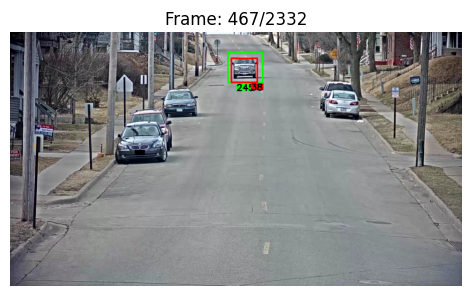

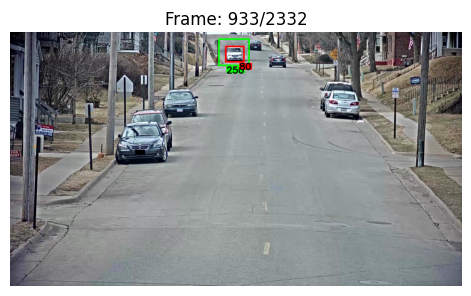

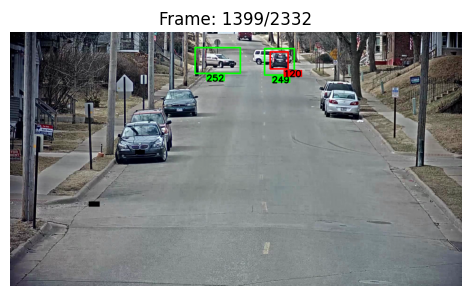

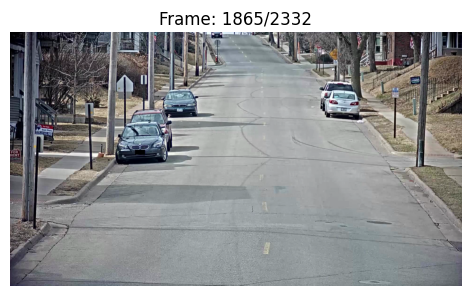

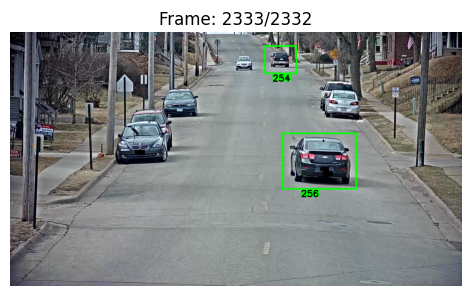

In [58]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )

### C015

In [17]:
tracking[1],annotations[1]

([{'bbox': [705.92, 265.02, 68.82, 79.4], 'conf': 1.0, 'track_id': 1},
  {'bbox': [703.61, 250.64, 53.1, 38.39], 'conf': 1.0, 'track_id': 2},
  {'bbox': [750.33, 342.68, 42.85, 61.95], 'conf': 1.0, 'track_id': 4},
  {'bbox': [671.6, 133.16, 54.73, 49.86], 'conf': 1.0, 'track_id': 5},
  {'bbox': [689.89, 221.43, 57.54, 46.09], 'conf': 1.0, 'track_id': 6},
  {'bbox': [709.25, 283.03, 65.65, 34.25], 'conf': 1.0, 'track_id': 7},
  {'bbox': [708.65, 298.96, 61.86, 30.03], 'conf': 1.0, 'track_id': 8},
  {'bbox': [664.55, 89.36, 39.49, 34.48], 'conf': 1.0, 'track_id': 9}],
 [])

In [20]:
annotations[952]

[{'bbox': [820.0, 715.0, 467.0, 362.0], 'conf': 1.0, 'track_id': 241}]

In [25]:
annotations

defaultdict(list,
            {952: [{'bbox': [820.0, 715.0, 467.0, 362.0],
               'conf': 1.0,
               'track_id': 241}],
             953: [{'bbox': [831.0, 699.0, 440.0, 364.0],
               'conf': 1.0,
               'track_id': 241}],
             954: [{'bbox': [850.0, 694.0, 396.0, 340.0],
               'conf': 1.0,
               'track_id': 241}],
             955: [{'bbox': [858.0, 679.0, 389.0, 339.0],
               'conf': 1.0,
               'track_id': 241}],
             956: [{'bbox': [853.0, 638.0, 424.0, 382.0],
               'conf': 1.0,
               'track_id': 241}],
             957: [{'bbox': [877.0, 659.0, 401.0, 304.0],
               'conf': 1.0,
               'track_id': 241}],
             958: [{'bbox': [883.0, 617.0, 442.0, 358.0],
               'conf': 1.0,
               'track_id': 241}],
             959: [{'bbox': [911.0, 631.0, 453.0, 296.0],
               'conf': 1.0,
               'track_id': 241}],
             960: [{'b

In [14]:

seq = "S03"
cam = "c015"
tracking = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/mtsc/{trackname}.txt")#

annotations = parse_tracking_file(f"{path_to_mtmc_train}/train/{seq}/{cam}/gt/gt.txt")

calculate_metrics_taking_only_GTobject_into_account(tracking, annotations)
# calculate_metrics(tracking, annotations)


Identity Config:
THRESHOLD            : 0.5                           
PRINT_CONFIG         : True                          


({'HOTA': array([1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        , 0.7       , 0.61904762, 0.47826087,
         0.25925926, 0.03030303, 0.        , 0.        ]),
  'DetA': array([1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        , 0.7       , 0.61904762, 0.47826087,
         0.25925926, 0.03030303, 0.        , 0.        ]),
  'AssA': array([1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        , 0.7       , 0.61904762, 0.47826087,
         0.25925926, 0.03030303, 0.        , 0.        ]),
  'DetRe': array([1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        , 1.        , 1.        , 1.        ,
         1.        , 1.        

* vis only pred objects related to GT

In [23]:
vis_tracking = {k:v for k,v in tracking.items()}

In [27]:
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
video_player.plot(
        start_frame=952,
        end_frame=968,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking
    )

(5, 3)


In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=True,
        save_file=save_file
    )

* vis all preds

In [ ]:
numframe = parse_numframe_file(f"{path_to_mtmc_train}/cam_framenum/{seq}.txt")[cam]
video_path = f'{path_to_mtmc_train}/train/{seq}/{cam}/vdo.avi'
video_player = VideoPlayer(video_path)
num_chunks = 5
chunk_size = numframe // num_chunks  # integer division

for i in range(num_chunks):
    # Compute start and end frame for chunk i (frames are assumed to start at 1)
    start_frame = i * chunk_size + 1
    # For the last chunk, ensure we go to the end of the video
    if i == num_chunks - 1:
        end_frame = numframe + 1  # +1 because end_frame is exclusive
    else:
        end_frame = (i + 1) * chunk_size + 1

    save_file = f"{seq}/{cam}/{trackname}{i+1}_allpred.mp4"
    print(f"Chunk {i+1}: start_frame={start_frame}, end_frame={end_frame}, saving to {save_file}")

    video_player.plot(
        start_frame=start_frame,
        end_frame=end_frame,
        bounding_boxes_gt=annotations,
        bounding_boxes_pred=vis_tracking,
        taking_only_GTobject_into_account=False,
        save_file=save_file
    )